# Introduction

In this project, you will build a neural network of your own design to evaluate the CIFAR-10 dataset.
Our target accuracy is 70%, but any accuracy over 50% is a great start.
Some of the benchmark results on CIFAR-10 include:

78.9% Accuracy | [Deep Belief Networks; Krizhevsky, 2010](https://www.cs.toronto.edu/~kriz/conv-cifar10-aug2010.pdf)

90.6% Accuracy | [Maxout Networks; Goodfellow et al., 2013](https://arxiv.org/pdf/1302.4389.pdf)

96.0% Accuracy | [Wide Residual Networks; Zagoruyko et al., 2016](https://arxiv.org/pdf/1605.07146.pdf)

99.0% Accuracy | [GPipe; Huang et al., 2018](https://arxiv.org/pdf/1811.06965.pdf)

98.5% Accuracy | [Rethinking Recurrent Neural Networks and other Improvements for ImageClassification; Nguyen et al., 2020](https://arxiv.org/pdf/2007.15161.pdf)

Research with this dataset is ongoing. Notably, many of these networks are quite large and quite expensive to train. 

## Imports

In [1]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Note:

Please note that I have used code from my AI Programming w/ Python Nanodegree repository, found at: https://github.com/kinant/ud-ai-python-nd.
More specifically, I have borrowed some functions, like the ones for getting the best accelerator or cuda device (if available). I have also used similar structure for my code, but it is more robust now, as I have been learning and practicing more.

## Load the Dataset

Specify your transforms as a list first.
The transforms module is already loaded as `transforms`.

CIFAR-10 is fortunately included in the torchvision module.
Then, you can create your dataset using the `CIFAR10` object from `torchvision.datasets` ([the documentation is available here](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [2]:
# Getting an error with Jupyter Notebook Kernel shutting down. Running this cell fixes error. (Only happens when using matplotlib)
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [3]:
# DEFINING CONSTANTS
BATCH_SIZE = 64
IMAGE_SIZE = (32, 32, 3) #Image Height, Image Width, Color Channels

# AUGMENTATION
ROTATION = 35

# MEAN AND STD FOR NORMALIZING
# https://stackoverflow.com/questions/66678052/how-to-calculate-the-mean-and-the-std-of-cifar10-data/69699979#69699979
MEAN = [0.4914, 0.4822, 0.4465]
STD  = [0.2470, 0.2435, 0.2616]

In [4]:
# Define transforms
# For training, we will augment the data with RandomRotation and RandomHorizontalFlip
train_transform = transforms.Compose([
    transforms.RandomRotation(ROTATION),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# For testing, we do a "normal" transform
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Create training set and define training dataloader
train_set = torchvision.datasets.CIFAR10(root='~/.pytorch/CIFAR_10_data/', train=True, download=True, transform=train_transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

# Create test set and define test dataloader
test_set = torchvision.datasets.CIFAR10(root='~/.pytorch/CIFAR_10_data/', train=False, download=True, transform=test_transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# Will use this dict later for training
dataloaders = {
    "train": train_loader,
    "test": test_loader
}

# The 10 classes in the dataset
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [5]:
# Sanity Check, print classes and batch image shape
print(train_set.classes)
image_batch = next(iter(train_loader))[0]
print(image_batch.shape)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
torch.Size([64, 3, 32, 32])


In [6]:
# Sanity Check, print data loaders information
print("========== DATA SETS ==========")
print(f"Length of train dataset: {len(train_set)}")
print(f"Length of test dataset: {len(test_set)}")
print()
print("========== DATA LOADERS ==========")
print(f"Length of train loader: {len(train_loader)}")
print(f"Length of test loader: {len(test_loader)}")
print()
print(f"Images in dataset: {len(train_loader.dataset)}")
print(f"Length of test dataset: {len(test_loader.dataset)}")

========== DATA SETS ==========
Length of train dataset: 50000
Length of test dataset: 10000

========== DATA LOADERS ==========
Length of train loader: 782
Length of test loader: 157

Images in dataset: 50000
Length of test dataset: 10000


## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

### Data Set Information

In [7]:
batch = next(iter(train_loader))[0]
print(f"Train loader length: {len(train_loader)}")
print(f"Training Batch Size: {len(batch)}")
print(f"Training Batch Shape: {batch.shape}")
print()
image = batch[0][0:5]
print(f"Training Image Shape: {image.shape}")

Train loader length: 782
Training Batch Size: 64
Training Batch Shape: torch.Size([64, 3, 32, 32])

Training Image Shape: torch.Size([3, 32, 32])


With this information, we can verify that the images are 32x32 pixels with 3 color channels and that there are 64 images per train loader batch.

In [8]:
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(classes[labels[i]])
    
        image = images[i].numpy()
        plt.imshow(image.T)
        plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.8685879].


car


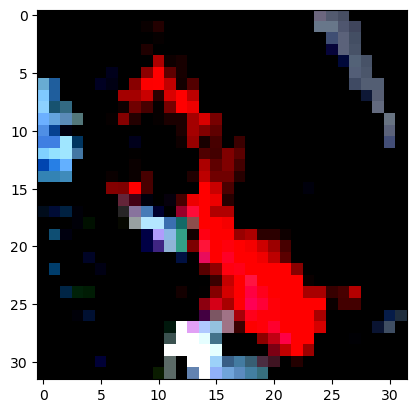

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.801021].


ship


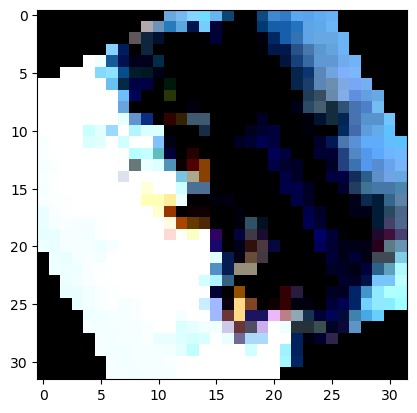

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0942786].


ship


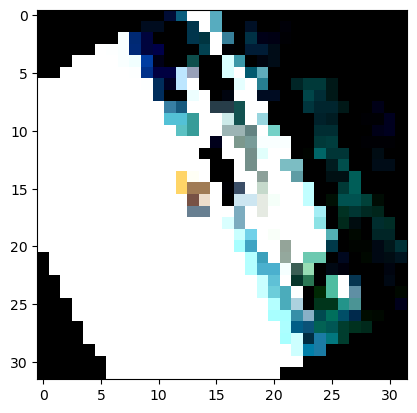

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.3764071].


deer


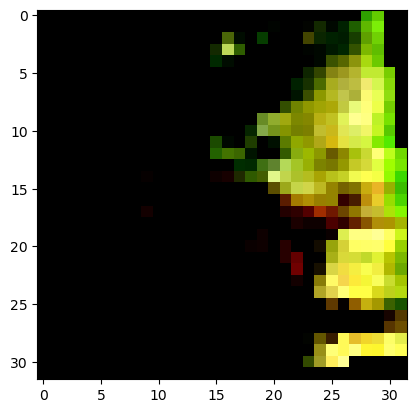

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.5669287].


dog


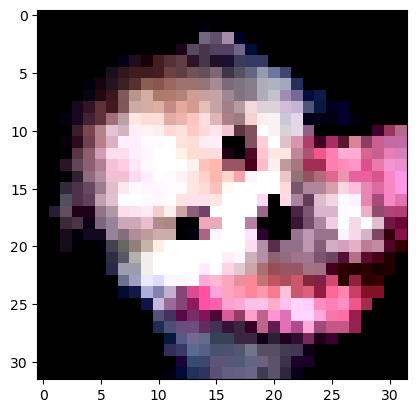

In [9]:
# Explore data
show5(train_loader);

## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset. 
Feel free to construct a model of any architecture – feedforward, convolutional, or even something more advanced!

I have used the following tutorial as a starting point, implementing the same simple CNN that they show, but in Keras.:
https://www.tensorflow.org/tutorials/images/cnn

**Information Known:**
Input Size is (3x32x32)

**Model Architecture to Implement:**
-Conv2d - Kernel Size: 3x3 and Output Channels: 32 (Output Shape: 32x30x30)
-MaxPool2D - Kernel Size: 2x2 (Output Shape: 32x15x15)
-Conv2d - Kernel Size: 3x3 and Output Channels: 64 (Output Shape: 64x13x13)
-MaxPool2D - Kernel Size: 2x2 (Output Shape: 64x4x4)
-Conv2d - Kernel Size: 3x3 and Output Channels: 64 (Output Shape: 64x4x4)

--Then we flatten-- resulting in an input to the dense layer of 64\*4\*4 = 1024

-Linear - In: 1024, Out: 64
-Linear - In: 64, Out: 10

**Reasoning**
I initially tried building my own networks, but it was proving very time-consuming. I decided to use a very simple CNN because it is good for image classification tasks.


In [10]:
# Network Architecture Definition
class Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        # Define the Convolutional Layers
        self.conv32 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3)
        self.conv64 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3)
        self.conv32_64 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3)

        # Define Pooling Layers
        self.pool = nn.MaxPool2d(2, 2)

        # Define the fully connected or dense layers
        self.fc1 = nn.Linear(1024, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv32(x))) # CONV OUTPUT (32x30x30) -> POOL OUTPUT (32x15x15)
        x = self.pool(F.relu(self.conv32_64(x))) # CONV OUTPUT (64x13x13) -> POOL OUTPUT (64x6x6)
        x = F.relu(self.conv64(x)) # CONV OUTPUT (64x4x4)

        x = torch.flatten(x, 1) # flatten all dimensions except batch

        x = F.relu(self.fc1(x))
        x = self.fc2(x) # NOTE: Output layer will return logits and not logit probabilities, since we are using CrossEntropyLoss as loss function
        return x

Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [11]:
# These will only be temporary. I instantiate model, criterion and optimizer for training the network in the training section
model_tmp = Classifier()

# We use CrossEntropyLoss as the loss function, since it combines
# As per the pyTorch documentation, CrossEntropyLoss is useful for training classification problems
# https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html
# we use reduction="sum", since my metrics will be calculated using the total loss (sum of all the losses)
criterion_tmp = nn.CrossEntropyLoss(reduction="sum")
optimizer_tmp = optim.SGD(model_tmp.parameters(), lr=0.001, momentum=0.9)

In [12]:
# Sanity Check, print model
print(type(model_tmp))
print(model_tmp)

<class '__main__.Classifier'>
Classifier(
  (conv32): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv64): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv32_64): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


### Model Summary:
We can use torchinfo to print a summary of a model, using the summary() function.

In [13]:
try:
    from torchinfo import summary
except ModuleNotFoundError:
    print("torchinfo not found.")
else:
    print(summary(model_tmp, input_size=[BATCH_SIZE, 3, 32, 32], col_names=["input_size", "output_size", "num_params"]))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Classifier                               [64, 3, 32, 32]           [64, 10]                  --
├─Conv2d: 1-1                            [64, 3, 32, 32]           [64, 32, 30, 30]          896
├─MaxPool2d: 1-2                         [64, 32, 30, 30]          [64, 32, 15, 15]          --
├─Conv2d: 1-3                            [64, 32, 15, 15]          [64, 64, 13, 13]          18,496
├─MaxPool2d: 1-4                         [64, 64, 13, 13]          [64, 64, 6, 6]            --
├─Conv2d: 1-5                            [64, 64, 6, 6]            [64, 64, 4, 4]            36,928
├─Linear: 1-6                            [64, 1024]                [64, 64]                  65,600
├─Linear: 1-7                            [64, 64]                  [64, 10]                  650
Total params: 122,570
Trainable params: 122,570
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 293.72
Inp

In [14]:
# Set all to None, so I do not accidentally use them when training
model_tmp = None
criterion_tmp = None
optimizer_tmp = None

## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss during each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

#### **IMPORTANT NOTE**:

I have used my previous project (Image Classifier) from AI Programming w/ Python as a reference for this project.
Repo @: https://github.com/kinant/ud-ai-python-nd/tree/main/PR02

In [15]:
# For deep copying model state dict when saving
from copy import deepcopy
# For timing
from timeit import default_timer as timer

General Functions for getting CUDA device (if available)

In [16]:
def get_best_cuda_device() -> torch.device:
    """
    Function to get the best cuda device
    Assumptions:    there is a CUDA device available
    Reasoning:      Can be used when a machine has more than one GPU available for example
                    As for example, my machine has an RTX4090 and an RTX5090
    Reference: # https://docs.pytorch.org/docs/stable/generated/torch.cuda.get_device_capability.html
    :return: the best cuda device based on device major cuda capability
    """

    # Get the max index of the device with the best major cuda capability
    # We use the max function with a list of the device ids (as ints)
    # and the major device capability (index 0) as the key
    best_device = max(
        range(torch.cuda.device_count()),
        key=lambda i: torch.cuda.get_device_capability(i)[0]
    )
    # Return the best cuda device, based on major device capability
    return torch.device(f"cuda:{best_device}")

def get_device(override: str = None) -> torch.device:
    """
    Function to get the device to use by PyTorch
    :param override: Optional override for device
    :return: The best device available or the overridden device
    Reference: https://mctm.web.id/blog/2024/PyTorchGPUSelect/
    """
    # Check not overriding device to use
    if not override:
        # Step 1: Check if CUDA is available
        if torch.cuda.is_available():
            # If so, return the best CUDA device
            return get_best_cuda_device()
        # Step 2: If no CUDA, check if MPS enabled machine
        elif torch.backends.mps.is_available():
            # If so, return as device
            return torch.device("mps")
        # Step 3: If no CUDA and no MPS, then we return CPU
        else:
            return torch.device("cpu")
    else:
        # Else, if we are overriding, we specifically return
        # the device given by the argument (i.e. "cpu", "cuda", "cuda:0", "mps", etc)
        return torch.device(override)

### Training:
I have divided the training into two steps: training step and test step, as seen in: https://www.kaggle.com/code/tirendazacademy/cats-dogs-classification-with-pytorch

This made it much easier for me to calculate metrics and really make sure everything was implemented correctly.

In [17]:
def train_step(
        model: Classifier,
        dataloader: torch.utils.data.DataLoader,
        device: torch.types.Device,
        optimizer: torch.optim.Optimizer,
        criterion: torch.nn.CrossEntropyLoss) -> tuple[float, float]:
    """
    Function that performs one training step
    Reference used: https://www.kaggle.com/code/tirendazacademy/cats-dogs-classification-with-pytorch
    :param model: classifier model to be trained
    :param dataloader: dataloader to use for training
    :param device: device to be used
    :param optimizer: optimizer to be used
    :param criterion: loss function to be used
    :return: train loss and train accuracy of the step (once per epoch)
    """

    # Put the model in train mode
    model.train()

    # Init train loss total and train correct (# of correct predictions)
    total_train_loss, total_train_correct = 0.0, 0.0

    # iterate over inputs and labels in the dataloader
    for inputs, labels in dataloader:

        # set the device
        inputs, labels = inputs.to(device), labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(inputs)
        loss = criterion(output, labels)

        # Add to the training loss
        # Since we are using CrossEntropyLoss with reduce="sum"
        # This will sum all the losses (which is what I want)
        total_train_loss += loss.item()

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Find the predicted classes (highest scores)
        preds = torch.argmax(output, dim=1)

        # Update training corrects
        total_train_correct += torch.sum(preds == labels).item()

    # Calculate metrics
    train_loss = total_train_loss / len(dataloader.dataset) # Divide total losses by the number of images in the dataset (to get an average train loss metric)
    train_accuracy = total_train_correct / len(dataloader.dataset) # Divide correct predictions by the total number of images to get accuracy

    return train_loss, train_accuracy

In [18]:
def test_step(
        model: Classifier,
        dataloader: torch.utils.data.DataLoader,
        device: torch.types.Device,
        criterion: torch.nn.CrossEntropyLoss) -> tuple[float, float]:
    """
    Function that performs one test step
    Reference used: https://www.kaggle.com/code/tirendazacademy/cats-dogs-classification-with-pytorch
    :param model: classifier model to use to predict
    :param dataloader: dataloader to use for testing
    :param device: device to be used
    :param criterion: loss function to be used
    :return: loss and validation accuracy of the step (once per epoch)
    """

    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    total_test_loss, total_test_correct = 0.0, 0.0

    # Turn on inference context manager
    with torch.no_grad():
        # Loop through DataLoader batches
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # 1. Forward pass
            output = model(inputs)

            # 2. Calculate and accumulate loss
            loss = criterion(output, labels)
            total_test_loss += loss.item()

            # Calculate and accumulate accuracy
            preds = torch.argmax(output, dim=1)

            total_test_correct += torch.sum(preds == labels).item()

    # Adjust metrics to get average loss and accuracy
    test_loss = total_test_loss / len(dataloader.dataset)
    test_acc = total_test_correct / len(dataloader.dataset)
    return test_loss, test_acc

### Training the Network:

In [19]:
def train(model: Classifier,
        dataloaders: dict[str, torch.utils.data.DataLoader],
        device: torch.types.Device,
        optimizer: torch.optim.Optimizer,
        criterion: torch.nn.CrossEntropyLoss,
        num_epochs=10):
    """
    Function that trains the model
    :param model: classifier model to be trained
    :param dataloaders: dataloaders to use for training and validation
    :param device: device to be used
    :param optimizer: optimizer to be used
    :param criterion: loss function to be used
    :param num_epochs: number of epochs to train for
    :return: dictionary of the results of the training
    """

    results_dict = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # set the device
    model.to(device)

    # for the start time
    start_time = None

    # init best_state_dict to the initial state_dict (not trained)
    best_state_dict = deepcopy(model.state_dict())

    # to keep track of best accuracy
    best_acc = 0.0

    def get_iterator(num_epochs):
        # I happened to use a library called tqdm to show a progress bar
        # One can install it if they want
        # Here we check if we have it installed and then use it
        try:
            from tqdm.auto import tqdm
            print(f"tqdm found")
        except ModuleNotFoundError:
            print("'tqdm' not found, using normal range function")
            return range(num_epochs)
        else:
            return tqdm(range(num_epochs))

    iterator = get_iterator(num_epochs)

    # get the start time
    start_time = timer()

    # iterate over each epoch and perform the training and test steps
    for epoch in iterator:
        train_loss, train_acc = train_step(model, dataloaders["train"], device, optimizer, criterion)
        test_loss, test_acc = test_step(model, dataloaders["test"], device, criterion)

        # show the results and get the accuracy
        # Print Results
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc * 100:.2f}% | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc * 100:.2f}%"
        )

        results_dict["train_loss"].append(train_loss)
        results_dict["train_acc"].append(train_acc)
        results_dict["test_loss"].append(test_loss)
        results_dict["test_acc"].append(test_acc)

        # if we have better accuracy, then we set the new best_state_dict
        # and the new better accuracy
        if test_acc > best_acc:
            best_state_dict = deepcopy(model.state_dict())
            best_acc = test_acc

    # training complete, get the end time and show
    end_time = timer()
    elapsed_time = end_time - start_time
    print(f"Training Complete! Total training time: {elapsed_time} seconds")

    # Save best training weights
    model.load_state_dict(best_state_dict)

    # return the results dictionary (can be used for plotting)
    return results_dict, best_state_dict

In [20]:
# Sanity Check, get the device to use
device = get_device()
print(device)
print(torch.cuda.get_device_name(device))

cuda:1
NVIDIA GeForce RTX 5090


In [21]:
# Instantiate model, criterion (loss function) and optimizer (I do it here because I don't want to scroll all the way up again)
model = Classifier()
criterion = torch.nn.CrossEntropyLoss(reduction="sum")
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [22]:
# Train the network!
training_results, best_state = train(model, dataloaders, device, optimizer, criterion, num_epochs=15)
# print(training_results)

tqdm found


  0%|          | 0/15 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.5864 | train_acc: 42.18% | test_loss: 1.2823 | test_acc: 54.23%
Epoch: 2 | train_loss: 1.2834 | train_acc: 54.15% | test_loss: 1.1491 | test_acc: 59.41%
Epoch: 3 | train_loss: 1.1600 | train_acc: 58.79% | test_loss: 1.0471 | test_acc: 62.79%
Epoch: 4 | train_loss: 1.0852 | train_acc: 61.54% | test_loss: 0.9950 | test_acc: 64.95%
Epoch: 5 | train_loss: 1.0378 | train_acc: 63.12% | test_loss: 1.0031 | test_acc: 65.28%
Epoch: 6 | train_loss: 0.9945 | train_acc: 65.09% | test_loss: 0.9346 | test_acc: 66.53%
Epoch: 7 | train_loss: 0.9660 | train_acc: 65.88% | test_loss: 0.9031 | test_acc: 68.62%
Epoch: 8 | train_loss: 0.9314 | train_acc: 67.26% | test_loss: 0.9028 | test_acc: 68.81%
Epoch: 9 | train_loss: 0.9124 | train_acc: 67.74% | test_loss: 0.8875 | test_acc: 69.46%
Epoch: 10 | train_loss: 0.8950 | train_acc: 68.44% | test_loss: 0.8490 | test_acc: 70.99%
Epoch: 11 | train_loss: 0.8763 | train_acc: 68.96% | test_loss: 0.8662 | test_acc: 70.14%
Epoch: 12 | train_l

Plot the training loss (and validation loss/accuracy, if recorded).

In [23]:
def plot_loss_curves(results: dict[str, float]) -> None:
    """
    Function to plot loss curves
    Used as reference: https://www.kaggle.com/code/tirendazacademy/cats-dogs-classification-with-pytorch
    :param results: training results dictionary
    """

    # Get the loss values
    train_loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values
    train_accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Determine how many epochs
    epochs = range(len(results['train_loss']) + 1)[1:]

    # Setup plot
    plt.figure(figsize=(15, 7))

    # Plot losses
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss, label='train_loss')
    plt.plot(epochs, test_loss, label='test_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracies
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracy, label='train_accuracy')
    plt.plot(epochs, test_accuracy, label='test_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend();

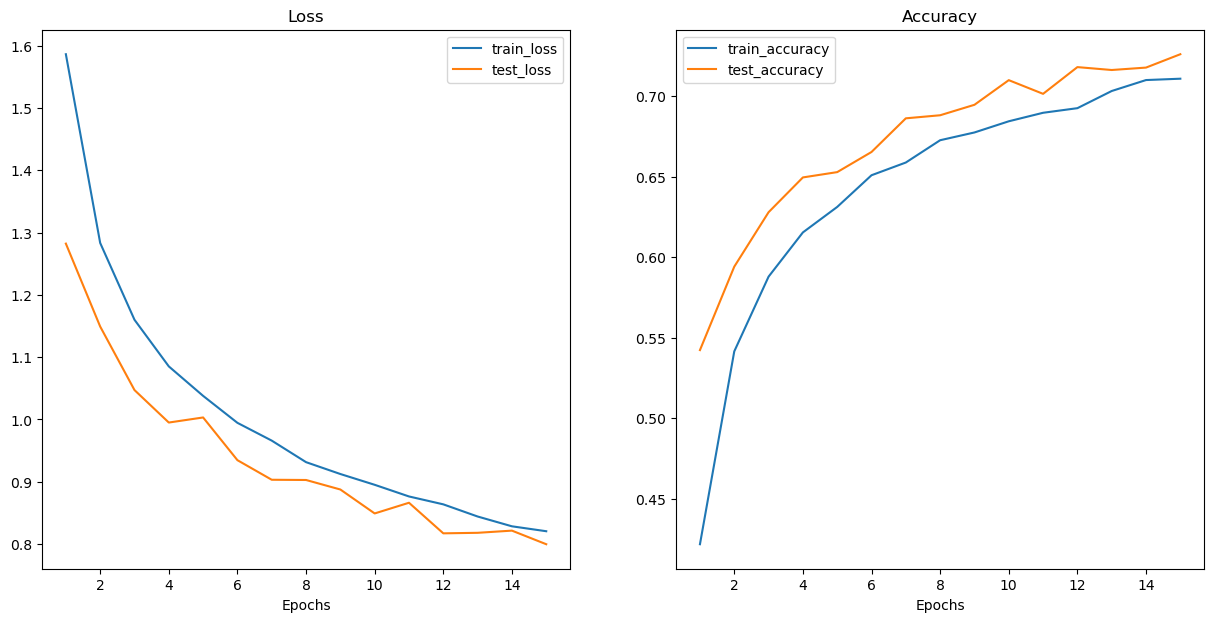

In [24]:
plot_loss_curves(training_results)

## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 70%, great work! 
This is a hard task to exceed 70% on.

If your accuracy is under 45%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [25]:
# Load the best state_dict obtained from training
model.load_state_dict(best_state)

<All keys matched successfully>

In [26]:
def check_accuracy_on_test_data(
        model: Classifier,
        device: torch.types.Device,
        dataloader: torch.utils.data.DataLoader) -> None:
    """
    Function that checks accuracy on test data
    :param model: model for inference
    :param device: device to be used
    :param dataloader: the test dataloader
    """

    # To keep track of correct inferences
    correct = 0

    # set the device
    model.to(device)

    with torch.no_grad():
        # iterate over each batch of inputs and labels in the test dataloader
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # get the probability logits
            output = model(inputs)

            # get the top result
            preds = torch.argmax(output, dim=1)

            # we sum the above up to get update the number of corrects
            correct += torch.sum(preds == labels).item()

    # Once done, we print the accuracy of the network on test images
    print(f"Accuracy of the network on the test images:{(correct / len(dataloader.dataset)) * 100:.2f}%")

In [27]:
check_accuracy_on_test_data(model, device, dataloaders["test"])

Accuracy of the network on the test images:72.60%


## Saving your model
Using `torch.save`, save your model for future loading.

In [28]:
torch.save(model.state_dict(), "checkpoint.pth")

## Make a Recommendation

Based on your evaluation, what is your recommendation on whether to build or buy? Explain your reasoning below.

We were able to obtain an accuracy on the test set of 72.60% using a simple CNN. My recommendation would be to build rather than buy, since we have shown that an accuracy of 70% is possible. With proper datasets and fine-tuning, I think they can build a CNN Image Classifier that can meet or exceed their needs. I can imagine much more complex CNNs can achieve better results. And since they would own the code, then they can easily make changes or even use pre-trained models for future projects. Building gives them a flexibility that buying cannot, and in the long run, they can save money by not paying a third-party.